<a href="https://colab.research.google.com/github/kurexi/ml-labs/blob/main/Lab5_Excercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A little Linear Regression

In [1]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset

# fix random seed for reproducibility
seed = 7
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True

class MyDataset(Dataset):
  def __init__(self, size=5000, dim=40, random_offset=0):
        super(MyDataset, self).__init__()
        self.size = size
        self.dim = dim
        self.random_offset = random_offset

  def __getitem__(self, index):
      if index >= len(self):
          raise IndexError("{} index out of range".format(self.__class__.__name__))

      rng_state = torch.get_rng_state()
      torch.manual_seed(index + self.random_offset)

      while True:
        img = torch.zeros(self.dim, self.dim)
        dx = torch.randint(-10,10,(1,),dtype=torch.float)
        dy = torch.randint(-10,10,(1,),dtype=torch.float)
        c = torch.randint(-20,20,(1,), dtype=torch.float)

        params = torch.cat((dy/dx, c))
        xy = torch.randint(0,img.shape[1], (20, 2), dtype=torch.float)
        xy[:,1] = xy[:,0] * params[0] + params[1]

        xy.round_()
        xy = xy[ xy[:,1] > 0 ]
        xy = xy[ xy[:,1] < self.dim ]
        xy = xy[ xy[:,0] < self.dim ]

        for i in range(xy.shape[0]):
          x, y = xy[i][0], self.dim - xy[i][1]
          img[int(y), int(x)]=1
        if img.sum() > 2:
          break

      torch.set_rng_state(rng_state)
      return img.unsqueeze(0), params

  def __len__(self):
      return self.size

train_data = MyDataset()
val_data = MyDataset(size=500, random_offset=33333)
test_data = MyDataset(size=500, random_offset=99999)

In [2]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

In [11]:
def train(model):
  loss_function = nn.MSELoss()
  optimiser = optim.Adam(model.parameters())

  device = "cuda:0" if torch.cuda.is_available() else "cpu"

  model.to(device)

  epochs = 100
  loss_history = []
  test_loss_history = []
  for epoch in range(epochs):
    # train
    model.train()
    running_loss = 0.0
    for data in train_loader:
      inputs, labels = data
      inputs, labels = inputs.to(device), labels.to(device)
      predictions = model(inputs)
      loss = loss_function(predictions, labels)

      optimiser.zero_grad()

      loss.backward()

      optimiser.step()
      running_loss += loss.item()
    loss_history.append(running_loss / len(train_loader))
    print(f"Epoch: {epoch}. Batch Loss: {loss_history[-1]:.4f}")

    # evaluate
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
      for data in test_loader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        predictions = model(inputs)
        loss = loss_function(predictions, labels)
        test_loss += loss.item()
      test_loss_history.append(test_loss / len(test_loader))

  return loss_history, test_loss_history

In [7]:
import torch
from torch import nn
import torch.nn.functional as F
from torch import optim

class MyCNN(nn.Module):
  def __init__(self):
    super(MyCNN, self).__init__()
    self.conv1 = nn.Conv2d(1, 48, (3, 3), padding=1)
    self.fc1 = nn.Linear(48*40**2, 128)
    self.fc2 = nn.Linear(128, 2)

  # input size is default dim of Dataset: 40
  def forward(self, x):
    out = self.conv1(x)
    out = F.relu(out)
    out = out.view(out.shape[0], -1)
    # 40x40x48 => 128
    out = self.fc1(out)
    out = F.relu(out)
    return self.fc2(out)

model = MyCNN()

loss_history, test_loss_history = train(model)


Epoch: 0. Batch Loss: 64.7162
Epoch: 1. Batch Loss: 60.9496
Epoch: 2. Batch Loss: 54.7052
Epoch: 3. Batch Loss: 40.6982
Epoch: 4. Batch Loss: 28.4598
Epoch: 5. Batch Loss: 24.6030
Epoch: 6. Batch Loss: 23.4524
Epoch: 7. Batch Loss: 21.3858
Epoch: 8. Batch Loss: 20.1087
Epoch: 9. Batch Loss: 19.7481
Epoch: 10. Batch Loss: 20.2710
Epoch: 11. Batch Loss: 18.5831
Epoch: 12. Batch Loss: 17.9642
Epoch: 13. Batch Loss: 17.7273
Epoch: 14. Batch Loss: 16.9159
Epoch: 15. Batch Loss: 15.8800
Epoch: 16. Batch Loss: 14.7252
Epoch: 17. Batch Loss: 14.3605
Epoch: 18. Batch Loss: 14.2772
Epoch: 19. Batch Loss: 13.1259
Epoch: 20. Batch Loss: 12.1311
Epoch: 21. Batch Loss: 12.0967
Epoch: 22. Batch Loss: 11.7816
Epoch: 23. Batch Loss: 10.3133
Epoch: 24. Batch Loss: 10.1096
Epoch: 25. Batch Loss: 10.4720
Epoch: 26. Batch Loss: 9.0594
Epoch: 27. Batch Loss: 8.7713
Epoch: 28. Batch Loss: 8.1374
Epoch: 29. Batch Loss: 7.7137
Epoch: 30. Batch Loss: 7.4656
Epoch: 31. Batch Loss: 7.0503
Epoch: 32. Batch Loss: 6

MyCNN1: train=0.7253; test=16.2113


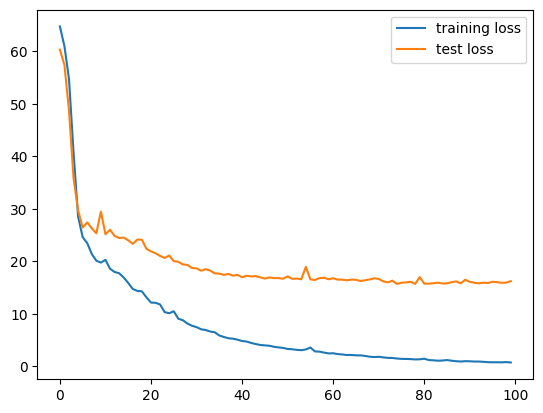

In [27]:
import matplotlib.pyplot as plt

print(f"MyCNN1: train={loss_history[-1]:.4f}; test={test_loss_history[-1]:.4f}")

plt.plot(range(len(loss_history)), loss_history, label="training loss")
plt.plot(range(len(test_loss_history)), test_loss_history, label="test loss")
plt.legend()
plt.show()

In [23]:
class MyCNN2(nn.Module):
  def __init__(self, input_channels=1):
    super(MyCNN2, self).__init__()
    self.conv1 = nn.Conv2d(input_channels, 48, (3, 3), padding=1)
    self.conv2 = nn.Conv2d(48, 48, (3, 3), padding=1)
    self.fc1 = nn.Linear(48, 128)
    self.fc2 = nn.Linear(128, 2)

  # input size is default dim of Dataset: 40
  def forward(self, x):
    out = self.conv1(x)
    out = F.relu(out)
    out = self.conv2(out)
    out = F.relu(out)
    out = F.adaptive_max_pool2d(out, (1, 1))
    out = out.view(out.shape[0], -1)
    # 48 => 128
    out = self.fc1(out)
    out = F.relu(out)
    return self.fc2(out)

model2 = MyCNN2()

loss_history2, test_loss_history2 = train(model2)

Epoch: 0. Batch Loss: 62.8656
Epoch: 1. Batch Loss: 54.6061
Epoch: 2. Batch Loss: 41.7430
Epoch: 3. Batch Loss: 29.6824
Epoch: 4. Batch Loss: 26.8244
Epoch: 5. Batch Loss: 24.7943
Epoch: 6. Batch Loss: 23.5234
Epoch: 7. Batch Loss: 22.7009
Epoch: 8. Batch Loss: 21.7399
Epoch: 9. Batch Loss: 19.9210
Epoch: 10. Batch Loss: 18.3190
Epoch: 11. Batch Loss: 18.0098
Epoch: 12. Batch Loss: 17.0283
Epoch: 13. Batch Loss: 17.1244
Epoch: 14. Batch Loss: 16.9315
Epoch: 15. Batch Loss: 16.1166
Epoch: 16. Batch Loss: 15.8103
Epoch: 17. Batch Loss: 16.1817
Epoch: 18. Batch Loss: 15.3865
Epoch: 19. Batch Loss: 15.7512
Epoch: 20. Batch Loss: 15.2823
Epoch: 21. Batch Loss: 14.9932
Epoch: 22. Batch Loss: 15.1250
Epoch: 23. Batch Loss: 15.2504
Epoch: 24. Batch Loss: 15.4517
Epoch: 25. Batch Loss: 14.7147
Epoch: 26. Batch Loss: 15.2967
Epoch: 27. Batch Loss: 15.0656
Epoch: 28. Batch Loss: 14.4817
Epoch: 29. Batch Loss: 14.3170
Epoch: 30. Batch Loss: 14.4972
Epoch: 31. Batch Loss: 14.8534
Epoch: 32. Batch L

MyCNN2: train=12.0570; test=15.9880


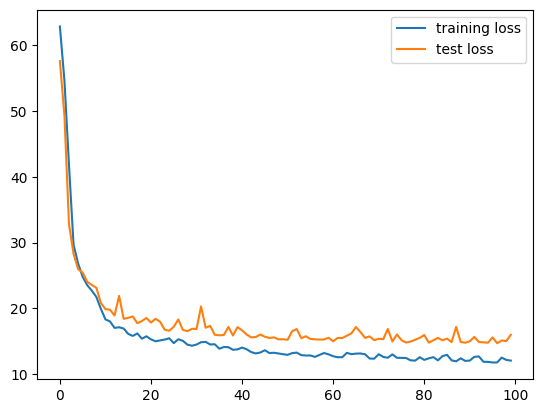

In [28]:
print(f"MyCNN2: train={loss_history2[-1]:.4f}; test={test_loss_history2[-1]:.4f}")

plt.plot(range(len(loss_history2)), loss_history2, label="training loss")
plt.plot(range(len(test_loss_history2)), test_loss_history2, label="test loss")
plt.legend()
plt.show()

In [25]:
class MyCNN3(MyCNN2):
  def __init__(self):
    super(MyCNN3, self).__init__(3)

  def forward(self, x):
    idxx = torch.repeat_interleave(
        torch.arange(-20, 20, dtype=torch.float).unsqueeze(0) / 40.0,
        repeats = 40, dim=0).to(x.device)
    idxy = idxx.clone().t()
    idx = torch.stack([idxx, idxy]).unsqueeze(0)
    idx = torch.repeat_interleave(idx, repeats=x.shape[0], dim=0)
    x = torch.cat([x, idx], dim=1)
    return super().forward(x)

model3 = MyCNN3()

loss_history3, test_loss_history3 = train(model3)

Epoch: 0. Batch Loss: 64.1558
Epoch: 1. Batch Loss: 46.7172
Epoch: 2. Batch Loss: 19.7392
Epoch: 3. Batch Loss: 12.9230
Epoch: 4. Batch Loss: 10.8130
Epoch: 5. Batch Loss: 8.9100
Epoch: 6. Batch Loss: 7.1528
Epoch: 7. Batch Loss: 5.9212
Epoch: 8. Batch Loss: 5.2428
Epoch: 9. Batch Loss: 4.9628
Epoch: 10. Batch Loss: 4.5234
Epoch: 11. Batch Loss: 4.2851
Epoch: 12. Batch Loss: 4.8121
Epoch: 13. Batch Loss: 3.7613
Epoch: 14. Batch Loss: 3.4380
Epoch: 15. Batch Loss: 3.3548
Epoch: 16. Batch Loss: 3.2483
Epoch: 17. Batch Loss: 3.1159
Epoch: 18. Batch Loss: 3.0929
Epoch: 19. Batch Loss: 2.8787
Epoch: 20. Batch Loss: 2.9867
Epoch: 21. Batch Loss: 2.7195
Epoch: 22. Batch Loss: 2.9214
Epoch: 23. Batch Loss: 2.5238
Epoch: 24. Batch Loss: 2.4995
Epoch: 25. Batch Loss: 2.5236
Epoch: 26. Batch Loss: 2.3479
Epoch: 27. Batch Loss: 2.4047
Epoch: 28. Batch Loss: 2.2999
Epoch: 29. Batch Loss: 2.2652
Epoch: 30. Batch Loss: 2.2618
Epoch: 31. Batch Loss: 2.2273
Epoch: 32. Batch Loss: 2.0300
Epoch: 33. Batc

MyCNN3: train=0.9126; test=1.1869


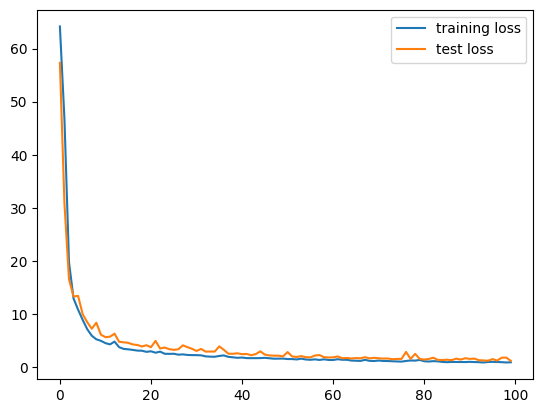

In [30]:
print(f"MyCNN3: train={loss_history3[-1]:.4f}; test={test_loss_history3[-1]:.4f}")

plt.plot(range(len(loss_history3)), loss_history3, label="training loss")
plt.plot(range(len(test_loss_history3)), test_loss_history3, label="test loss")
plt.legend()
plt.show()